# Linear Regression

## Simple Linear Regression (OLS)

In [157]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

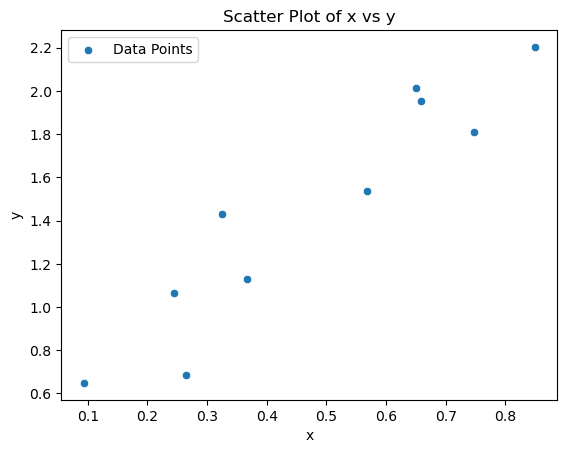

In [158]:
x = np.random.rand(10, 1)
y = 2 * x + 0.8 * np.random.rand(10, 1)
# x.shape, y.shape
df = pd.DataFrame(x, columns=["X"])
df["y"] = y
# df.head()
sns.scatterplot(data=df, x="X", y="y", label="Data Points")
plt.legend()  # or plt.legend(loc="best")
plt.title("Scatter Plot of x vs y")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

`ybar = w1 + w0 * xbar`

`xybar = w1 * xbar + w0 * x2bar`

In [159]:
xbar = df["X"].mean()
ybar = df["y"].mean()
xybar = (df["X"] * df["y"]).mean()
x2bar = (df["X"] ** 2).mean()

A = np.array([[xbar, 1],
              [x2bar, xbar]])
b = np.array([ybar, xybar])

solution = np.linalg.solve(A, b)
w0, w1 = solution
print("w0 (intercept):", w0)
print("w1 (slope):", w1)
x_vals = np.linspace(df["X"].min(), df["X"].max(), 100)
y_vals = w0 * x_vals + w1
    
# plt.plot(x_vals, y_vals, "r-")


w0 (intercept): 2.0765068035883822
w1 (slope): 0.45743596575634854


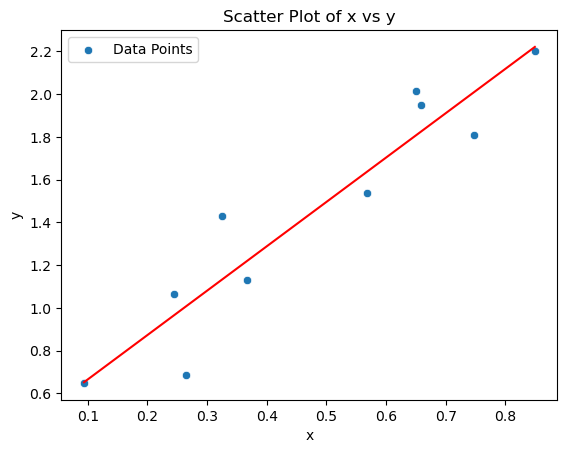

In [160]:
sns.scatterplot(data=df, x="X", y="y", label="Data Points")
plt.plot(x_vals, y_vals, "r-")
plt.legend()  # or plt.legend(loc="best")
plt.title("Scatter Plot of x vs y")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Linear Regression (gradient descent)

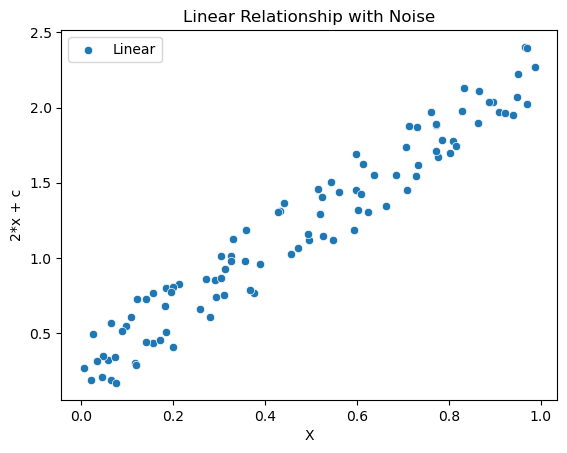

In [161]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)




# Create datasets
x = np.random.rand(100, 1)
y = 2 * x + 0.5 * np.random.rand(100, 1)

# Create DataFrame
df = pd.DataFrame(x, columns=["x"])
df["y"] = y

# Add outliers (e.g., 5 extreme points)
outliers_x = np.random.rand(5, 1)
outliers_y = 5 + np.random.rand(5, 1) * 5  # much larger y-values

# Add to original DataFrame
outliers_df = pd.DataFrame(outliers_x, columns=["x"])
outliers_df["y"] = outliers_y

df_with_outliers = pd.concat([df, outliers_df], ignore_index=True)
# print(outliers_df)

# df = df_with_outliers

# Plot
sns.scatterplot(data=df, x="x", y="y", label="Linear")
plt.xlabel("X")
plt.ylabel("2*x + c")
plt.title("Linear Relationship with Noise")
plt.legend()
plt.show()


In [162]:
x = df["x"]
y = df["y"]

w0 = np.random.rand(1)
w1 = np.random.rand(1)

alpha = 0.01
epochs = 10000
n = len(x)
w0, w1

# Gradient Descent Loop
for i in range(epochs):
    y_pred = w1 * x + w0
    error = y_pred - y
    
    # Compute gradients
    dw0 = (1/n) * np.sum(error)
    dw1 = (1/n) * np.sum(error * x)
    
    # Update weights
    w0 -= alpha * dw0
    w1 -= alpha * dw1

# print(f"Final weights:\nw0 (intercept): {w0:.4f}\nw1 (slope): {w1:.4f}")
w0.item(), w1.item()

(0.25728674452282063, 1.9822699036492104)

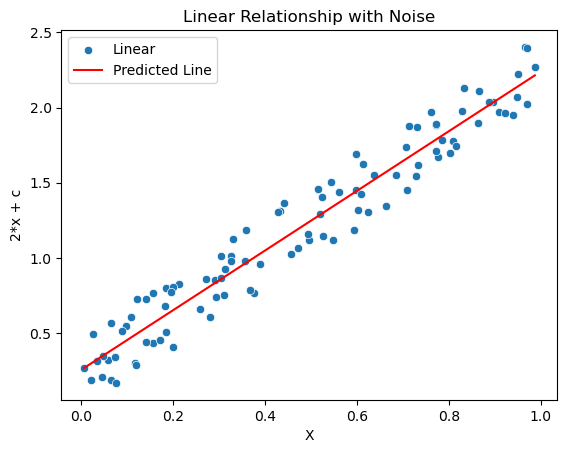

In [163]:
x_val = np.linspace(df["x"].min(), df["x"].max(), 1000)
y_val = w0 + w1 * x_val

sns.scatterplot(data=df, x="x", y="y", label="Linear")
plt.plot(x_val, y_val, "r-", label="Predicted Line")
plt.xlabel("X")
plt.ylabel("2*x + c")
plt.title("Linear Relationship with Noise")
plt.legend()
plt.show()

In [164]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = w0 + w1 * x

mse = mean_squared_error(y, y_pred)
r2score = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

mse, np.sqrt(mse), r2score, mae

(0.021239220800600065,
 0.14573682033240626,
 0.9419452033559588,
 0.1281392485817628)

## Practical

### Using Self (Gradient Descent)

In [253]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [254]:
df = pd.read_csv("weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [255]:
df.isnull().sum()

Gender    0
Height    0
Weight    0
dtype: int64

In [256]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# ohe = OneHotEncoder()
# ohe_gender = ohe.fit_transform(df[["Gender"]]).toarray()
# temp_df = pd.DataFrame(ohe_gender, columns=ohe.get_feature_names_out())
# temp_df.head()
# df = pd.concat([df, temp_df], axis=1)

ohe = LabelEncoder()
ohe_gender = ohe.fit_transform(df[["Gender"]])
temp_df = pd.DataFrame(ohe_gender, columns=["label_gender"])
# temp_df["label_gender"].unique()
df = pd.concat([df, temp_df], axis=1)
df.drop(columns=["Gender", "label_gender"], inplace=True)
df.head()

c:\Users\sande\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [268]:
# df.info()
# sns.pairplot(df)
corr = df.corr()
# sns.heatmap(corr, annot=True)
corr

,Height,Weight
Height,1.000000,0.924756
Weight,0.924756,1.000000


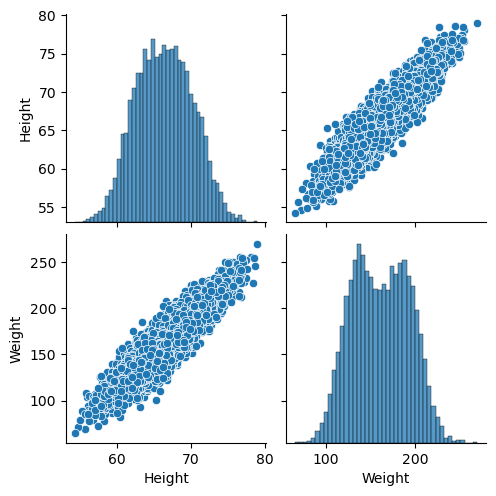

In [259]:
sns.pairplot(df)

In [260]:

X = df[["Height"]]
y = df["Weight"]


# train and test split datasets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

# Standardization (Z_score convert => mean = 0, var = 1)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8000, 1), (8000,), (2000, 1), (2000,))

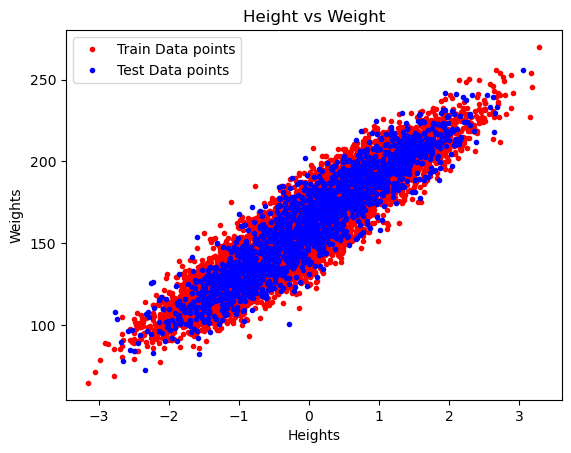

In [261]:
# sns.scatterplot(data=df, x = "Height", y="Weight", label="Data Points")
plt.plot(X_train, y_train, "r.", label="Train Data points")
plt.plot(X_test, y_test, "b.", label="Test Data points")

plt.legend()
plt.xlabel("Heights")
plt.ylabel("Weights")
plt.title("Height vs Weight")
plt.show()

In [262]:
w0 = np.random.rand(1)
w1 = np.random.rand(1)

# y_pred = w0 + w1 * x

epochs = 10000
learning_rate = 0.001

n = len(X_train)

for i in range(epochs):
    y_pred = w0 + w1 * X_train.ravel()
    error = (y_pred - y_train)
    # print(error.shape, y_pred.shape, y_train.shape)
    dw0 = (1/n) * np.sum(error)
    dw1 = (1/n) * np.sum(error * X_train.ravel())
    # print(dw0.shape, dw1.shape, error.shape, dw0, dw1)
    # break
    w0 -= learning_rate * dw0
    w1 -= learning_rate * dw1

print(dw0, dw1)



-0.00728297254369118 -0.0013282973570513973


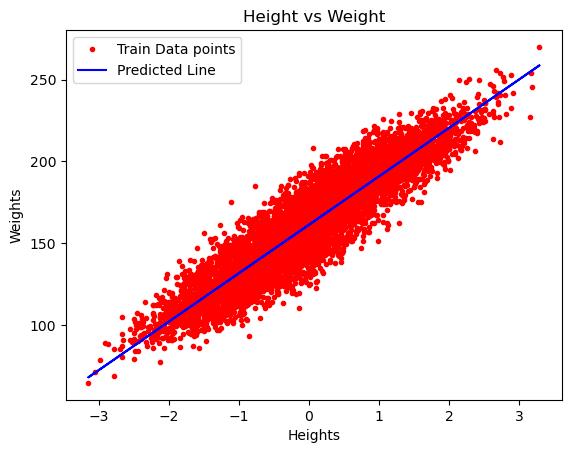

In [263]:
# sns.scatterplot(data=df, x = "Height", y="Weight", label="Data Points")

y_pred = w0 + w1 * X_train.ravel()

plt.plot(X_train, y_train, "r.", label="Train Data points")
plt.plot(X_train, y_pred, "b-", label="Predicted Line")

plt.legend()
plt.xlabel("Heights")
plt.ylabel("Weights")
plt.title("Height vs Weight")
plt.show()

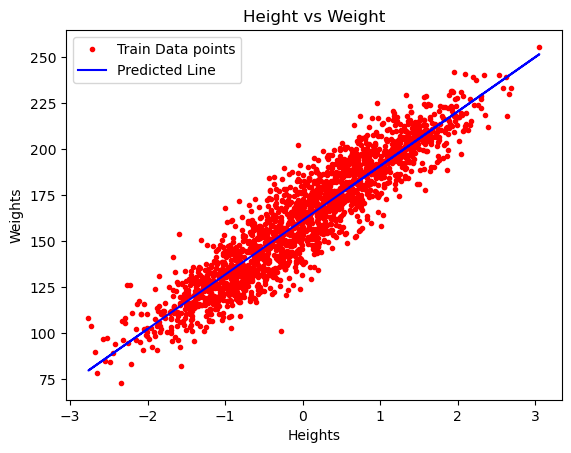

In [264]:
# sns.scatterplot(data=df, x = "Height", y="Weight", label="Data Points")

y_pred = w0 + w1 * X_test.ravel()

plt.plot(X_test, y_test, "r.", label="Train Data points")
plt.plot(X_test, y_pred, "b-", label="Predicted Line")

plt.legend()
plt.xlabel("Heights")
plt.ylabel("Weights")
plt.title("Height vs Weight")
plt.show()

### Using Sklearn Libary

In [265]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression(n_jobs=-1)
lr.fit(X_train,  y_train)
# lr.coef_, lr.intercept_, w1, w0
print("Linear Regression Library :: ", lr.coef_, lr.intercept_)
print("Linear Regression Self :: ", w1, w0)


Linear Regression Library ::  [29.61903439] 161.3267623130613
Linear Regression Self ::  [29.61770743] [161.31948662]


In [266]:
# Train Error
from sklearn.metrics import mean_absolute_error

y_pred_test = lr.predict(X_test)
y_pred_train =lr.predict(X_train)

y_pred_test_self = w0 + w1 * X_test.ravel()
y_pred_train_self = w0 + w1 * X_train.ravel()

mae_test = mean_absolute_error(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)

mae_test_self = mean_absolute_error(y_test, y_pred_test_self)
mae_train_self = mean_absolute_error(y_train, y_pred_train_self)

print("Self :: ", mae_test_self, mae_train_self)
print("Model :: ", mae_test, mae_train)

Self ::  9.692071025115682 9.760663104606513
Model ::  9.691933801884568 9.76071345543586


In [ ]:
from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred_test), r2_score(y_test, y_pred_test_self))

0.85773177770385 0.8577273115742793
